In [3]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import keras
import joblib

In [16]:
with open('utils/LowFidelity-PressureDistributionData.csv', 'r', encoding='utf-8') as f:
    header = f.readline().strip()

headers = header.split(';')

cp_headers = np.array([float(col) for col in headers[4:]])

with open('utils/HighFidelity-AviationInterpolated-PressureDistributionData.csv', 'r', encoding='utf-8') as f:
    header = f.readline().strip()

headers = header.split(';')

cp_headers_exp = np.array([float(col) for col in headers[4:]])

In [17]:
np.savetxt('teste_cp_headers_numerical.csv', cp_headers, delimiter=';', fmt='%.6f')

In [93]:
AoA_case = 7.835319753540942
y_case = 0.623510444
Re_case = 258308

In [ ]:
model = keras.models.load_model('utils/MLP-ANN.keras')

X_scaler = joblib.load('utils/mlp_ann_X_scaler.pkl')
y_scaler = joblib.load('utils/mlp_ann_y_scaler.pkl')

X_new = np.array([[Re_case, AoA_case, y_case]], dtype=np.float32)

X_new_scaled = X_scaler.transform(X_new)

y_pred_scaled = model.predict(X_new_scaled, verbose=0)

y_pred = y_scaler.inverse_transform(y_pred_scaled)

cp_pred = y_pred[0][1:]

In [4]:
experimental_data = pd.read_csv('utils/HighFidelity-AviationInterpolated-PressureDistributionData.csv', sep=';')

experimental_case = np.array(experimental_data[
    (experimental_data['Re'] == Re_case) &
    (experimental_data['AoA'] == AoA_case) & 
    (experimental_data['y'] == y_case)])[0]

experimental_case.shape

NameError: name 'Re_case' is not defined

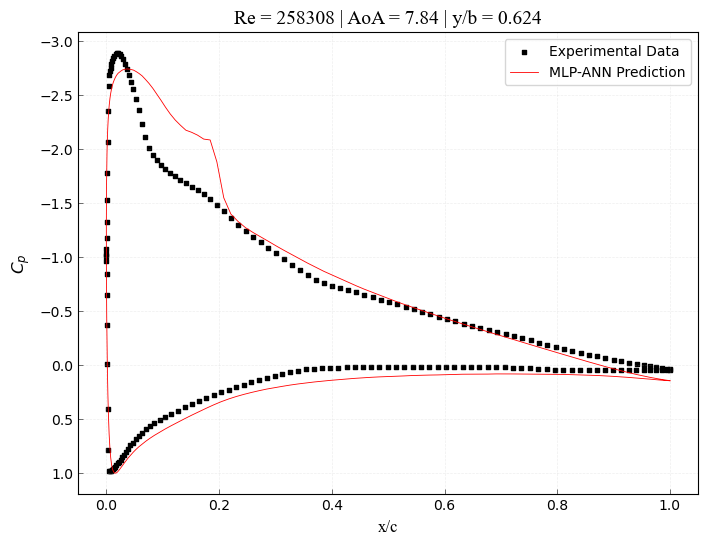

In [99]:
fig, ax = plt.subplots(figsize=(8, 6))
plot = ax.scatter(cp_headers_exp, experimental_case[4:], marker='s', s=6, color='k', label='Experimental Data')
plot = ax.plot(cp_headers, cp_pred, linestyle='-', linewidth=0.6, color='r', label='MLP-ANN Prediction')
ax.set_xlabel('x/c', fontsize=12, fontname='Times New Roman', labelpad=5)
ax.set_ylabel(r'$C_p$', fontsize=12, fontname='Times New Roman', labelpad=5)
Re, AoA, yb  = experimental_case[0], experimental_case[1], experimental_case[2]
ax.set_title(f'Re = {Re:.0f} | AoA = {AoA:.2f} | y/b = {yb:.3f}', fontsize=14, 
    fontname='Times New Roman')
ax.tick_params(axis='both', which='major', labelsize=10, width=0.4, direction='in')
ax.invert_yaxis()
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.2)
#ax.set_xlim(-0.05, 1.05)
#ax.set_ylim(1.1, -4)
ax.legend(loc='upper right', fontsize=10)
plt.show()

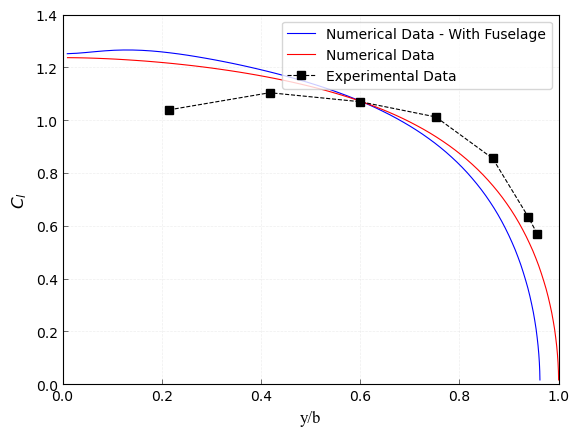

In [7]:
# 4000k Re - AoA = 10
y = np.array([0.222527415, 0.433896867, 0.623510444, 0.781856397, 0.900998695, 0.975, 0.994])*0.766/0.796
Cl = [1.039091476764661, 1.104090199107981, 1.0699858357327356, 1.012329340828689, 0.8552254671655677, 0.6350855973543184, 0.5707199704535938]


numerical_data = pd.read_csv('utils/LowFidelity-PressureDistributionData.csv', sep=';')

Re_case = 400000
AoA_case = 10

numerical_case = np.array(numerical_data[
    (numerical_data['Re'] == Re_case) &
    (numerical_data['AoA'] == AoA_case)])

y_num = numerical_case[:, 2]
cl_num = numerical_case[:, 3]

y_num_f = np.array([
    0.0075, 0.0226, 0.0376, 0.0526, 0.0676, 0.0826, 0.0975, 0.1124,
    0.1273, 0.1421, 0.1568, 0.1715, 0.1861, 0.2007, 0.2152, 0.2295,
    0.2438, 0.2581, 0.2722, 0.2862, 0.3001, 0.3138, 0.3275, 0.3410,
    0.3544, 0.3677, 0.3808, 0.3938, 0.4066, 0.4193, 0.4318, 0.4441,
    0.4563, 0.4683, 0.4801, 0.4917, 0.5032, 0.5144, 0.5255, 0.5363,
    0.5469, 0.5574, 0.5676, 0.5776, 0.5873, 0.5969, 0.6062, 0.6153,
    0.6241, 0.6327, 0.6411, 0.6492, 0.6570, 0.6646, 0.6720, 0.6791,
    0.6859, 0.6925, 0.6988, 0.7048, 0.7105, 0.7160, 0.7212, 0.7262,
    0.7308, 0.7352, 0.7392, 0.7430, 0.7466, 0.7498, 0.7527, 0.7554,
    0.7577, 0.7598, 0.7615, 0.7630, 0.7642, 0.7651, 0.7657, 0.7660
])/0.796

cl_num_f = [
    1.2519, 1.2535, 1.2564, 1.2597, 1.2627, 1.2649, 1.2659, 1.2658,
    1.2646, 1.2624, 1.2593, 1.2554, 1.2510, 1.2460, 1.2405, 1.2347,
    1.2286, 1.2221, 1.2154, 1.2084, 1.2011, 1.1936, 1.1858, 1.1778,
    1.1695, 1.1609, 1.1521, 1.1430, 1.1336, 1.1239, 1.1138, 1.1034,
    1.0927, 1.0816, 1.0701, 1.0583, 1.0460, 1.0332, 1.0201, 1.0064,
    0.9923, 0.9777, 0.9626, 0.9470, 0.9308, 0.9141, 0.8968, 0.8789,
    0.8604, 0.8414, 0.8217, 0.8014, 0.7804, 0.7589, 0.7367, 0.7139,
    0.6904, 0.6664, 0.6417, 0.6164, 0.5906, 0.5641, 0.5371, 0.5096,
    0.4815, 0.4529, 0.4238, 0.3943, 0.3644, 0.3341, 0.3034, 0.2723,
    0.2410, 0.2094, 0.1776, 0.1456, 0.1134, 0.0811, 0.0487, 0.0162
]

plt.plot(y_num_f, cl_num_f, color='b', linewidth=0.8, label = 'Numerical Data - With Fuselage')
plt.plot(y_num, cl_num, color='r', linewidth=0.8, label = 'Numerical Data')
plt.plot(y, Cl, marker='s', color='k', markersize=6, linestyle='--', linewidth=0.8, label = 'Experimental Data')
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.2)
plt.xlabel('y/b', fontsize=12, fontname='Times New Roman', labelpad=5)
plt.ylabel(r'$C_l$', fontsize=12, fontname='Times New Roman', labelpad=5)
plt.tick_params(axis='both', which='major', labelsize=10, width=0.4, direction='in')
plt.xlim(0, 1)
plt.ylim(0, 1.4)
plt.show()